In [ ]:
!pip install medmnist pennylane torch torchvision tqdm

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving medmnist.zip to medmnist.zip


In [ ]:
import zipfile
import os

ZIP_NAME = list(uploaded.keys())[0]   # uploaded zip file
DATA_DIR = "/content/medmnist"

os.makedirs(DATA_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_NAME, 'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)

print("ZIP extracted successfully!")
print("Classes:", os.listdir(DATA_DIR))


ZIP extracted successfully!
Classes: ['ChestCT', 'AbdomenCT', 'BreastMRI', 'CXR', 'HeadCT', 'Hand']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import pennylane as qml

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=transform
)

# Train–test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

NUM_CLASSES = len(dataset.classes)
print("Detected classes:", dataset.classes)


Detected classes: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeanCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Linear(16 * 4 * 4, 4)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [ ]:
class CNNOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = LeanCNN()
        self.fc = nn.Linear(4, NUM_CLASSES)

    def forward(self, x):
        x = self.cnn(x)
        return self.fc(x)


In [ ]:
cnn_model = CNNOnly().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

EPOCHS = 5

for epoch in range(EPOCHS):
    cnn_model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).long()
        if labels.dim() > 1:
            labels = labels.squeeze()

        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"CNN Epoch [{epoch+1}/{EPOCHS}] Loss: {total_loss/len(train_loader):.4f}")


CNN Epoch [1/5] Loss: 0.1883
CNN Epoch [2/5] Loss: 0.0434
CNN Epoch [3/5] Loss: 0.0328
CNN Epoch [4/5] Loss: 0.0266
CNN Epoch [5/5] Loss: 0.0206


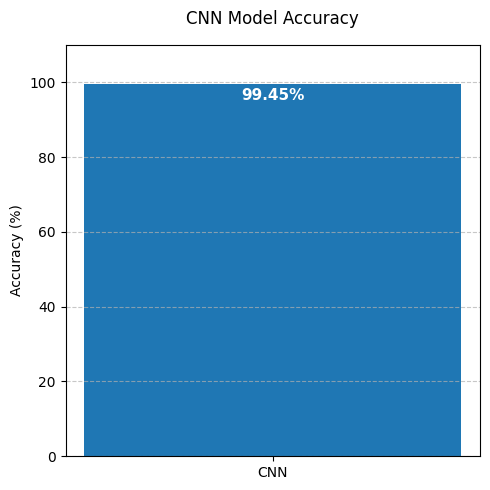

In [ ]:
import matplotlib.pyplot as plt
import torch

# Calculate CNN accuracy first
cnn_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).long()
        if labels.dim() > 1:
            labels = labels.squeeze()

        outputs = cnn_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

cnn_accuracy = 100 * correct / total

plt.figure(figsize=(5, 5))
bars = plt.bar(["CNN"], [cnn_accuracy])
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title("CNN Model Accuracy", pad=15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height - 5,
        f"{cnn_accuracy:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

plt.tight_layout()
plt.show()

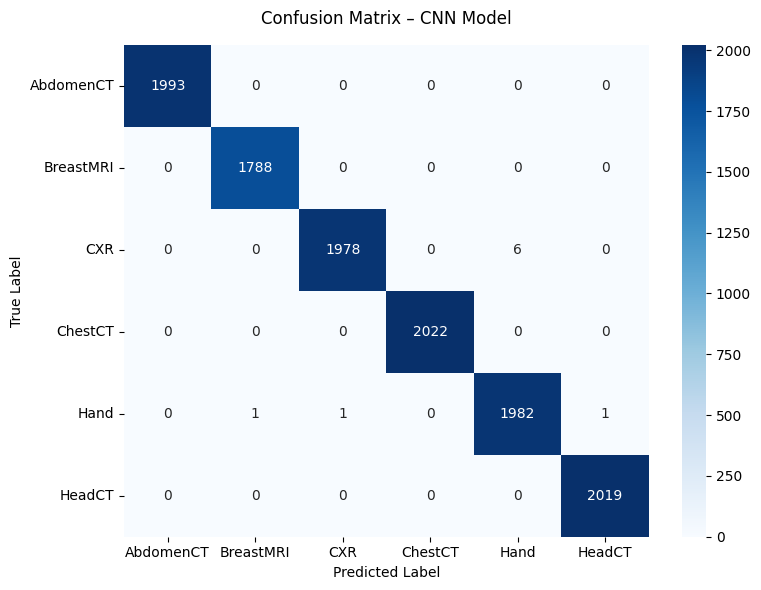

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

cnn_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).long()
        if labels.dim() > 1:
            labels = labels.squeeze()

        outputs = cnn_model(images)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – CNN Model", pad=15)
plt.tight_layout()
plt.show()


In [ ]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch

qkc_transform = transforms.Compose([
    transforms.Resize((8, 8)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.Lambda(lambda x: x.view(-1)[:4])  # 4 features
])

qkc_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=qkc_transform
)

NUM_CLASSES = len(qkc_dataset.classes)


In [ ]:
from collections import defaultdict
import random
import torch

SAMPLES_PER_CLASS = 50   # 6 classes → 300 samples
class_indices = defaultdict(list)

for idx, (_, label) in enumerate(qkc_dataset):
    class_indices[label].append(idx)

balanced_indices = []
for label in class_indices:
    balanced_indices.extend(
        random.sample(class_indices[label], SAMPLES_PER_CLASS)
    )

qkc_subset = torch.utils.data.Subset(qkc_dataset, balanced_indices)
print("QKC training samples:", len(qkc_subset))


QKC training samples: 300


In [ ]:
import numpy as np

X = []
y = []

for features, label in qkc_subset:
    X.append(features.numpy())
    y.append(label)

X = np.array(X)
y = np.array(y)


In [ ]:
import pennylane as qml

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

def feature_map(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])


In [ ]:
@qml.qnode(dev)
def kernel_circuit(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=range(n_qubits))

def quantum_kernel(x1, x2):
    return kernel_circuit(x1, x2)[0]


In [ ]:
N = len(X)
K = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        K[i, j] = quantum_kernel(X[i], X[j])


Quantum Kernel Classifier Accuracy: 81.67%


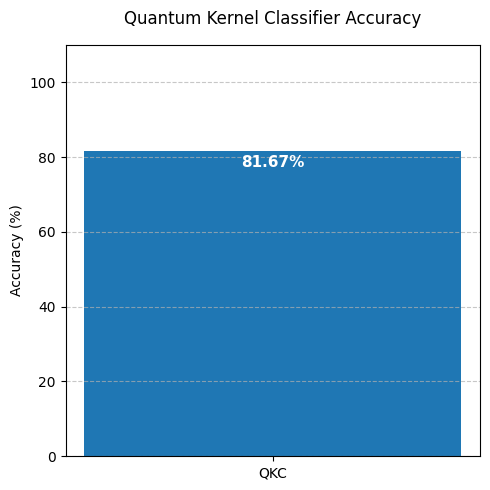

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

N = len(y)
indices = np.arange(N)

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

K_train = K[np.ix_(train_idx, train_idx)]
K_test  = K[np.ix_(test_idx, train_idx)]

y_train = y[train_idx]
y_test  = y[test_idx]

svm = SVC(kernel="precomputed")
svm.fit(K_train, y_train)
qkc_accuracy = svm.score(K_test, y_test) * 100
print(f"Quantum Kernel Classifier Accuracy: {qkc_accuracy:.2f}%")
plt.figure(figsize=(5, 5))
bars = plt.bar(["QKC"], [qkc_accuracy])
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title("Quantum Kernel Classifier Accuracy", pad=15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height - 5,
        f"{qkc_accuracy:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

plt.tight_layout()
plt.show()


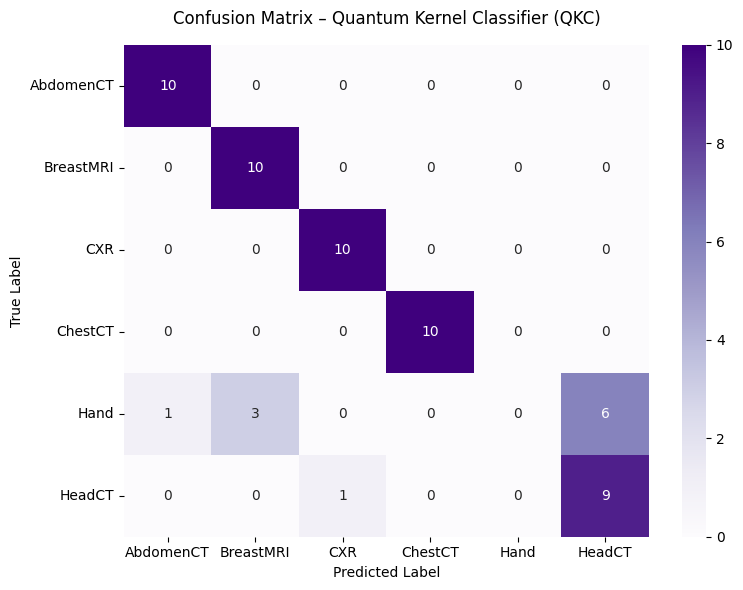

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
y_pred = svm.predict(K_test)
cm_qkc = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_qkc,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=qkc_dataset.classes,
    yticklabels=qkc_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Quantum Kernel Classifier (QKC)", pad=15)
plt.tight_layout()
plt.show()


In [ ]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch

hqnn_transform = transforms.Compose([
    transforms.Resize((8, 8)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.Lambda(lambda x: x.view(-1))  # flatten
])

hqnn_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=hqnn_transform
)

NUM_CLASSES = len(hqnn_dataset.classes)

train_size = int(0.8 * len(hqnn_dataset))
test_size = len(hqnn_dataset) - train_size

hqnn_train, hqnn_test = torch.utils.data.random_split(
    hqnn_dataset, [train_size, test_size]
)

hqnn_train_loader = DataLoader(hqnn_train, batch_size=32, shuffle=True)
hqnn_test_loader = DataLoader(hqnn_test, batch_size=32, shuffle=False)


In [ ]:
import pennylane as qml
import torch.nn as nn

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

def hqnn_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


In [ ]:
weight_shapes = {"weights": (1, n_qubits, 3)}

qnode = qml.QNode(
    hqnn_circuit,
    dev,
    interface="torch",
    diff_method="backprop"
)

hqnn_quantum_layer = qml.qnn.TorchLayer(qnode, weight_shapes)


In [ ]:
class HQNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8 * 8 * 3, 32)
        self.fc2 = nn.Linear(32, n_qubits)
        self.q_layer = hqnn_quantum_layer
        self.fc_out = nn.Linear(n_qubits, NUM_CLASSES)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.q_layer(x)
        return self.fc_out(x)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hqnn_model = HQNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(hqnn_model.parameters(), lr=0.001)

EPOCHS = 5

for epoch in range(EPOCHS):
    hqnn_model.train()
    total_loss = 0

    for features, labels in hqnn_train_loader:
        features = features.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()
        outputs = hqnn_model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] HQNN Loss: {total_loss/len(hqnn_train_loader):.4f}")



Epoch [1/10] HQNN Loss: 0.8020
Epoch [2/10] HQNN Loss: 0.1788
Epoch [3/10] HQNN Loss: 0.0788
Epoch [4/10] HQNN Loss: 0.0466
Epoch [5/10] HQNN Loss: 0.0298
Epoch [6/10] HQNN Loss: 0.0224
Epoch [7/10] HQNN Loss: 0.0188
Epoch [8/10] HQNN Loss: 0.0142
Epoch [9/10] HQNN Loss: 0.0127
Epoch [10/10] HQNN Loss: 0.0109


In [ ]:
hqnn_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for features, labels in hqnn_test_loader:
        features = features.to(device)
        labels = labels.to(device).long()

        outputs = hqnn_model(features)
        _, preds = torch.max(outputs, dim=1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

hqnn_accuracy = 100 * correct / total
print(f"HQNN Accuracy: {hqnn_accuracy:.2f}%")


HQNN Accuracy: 99.53%


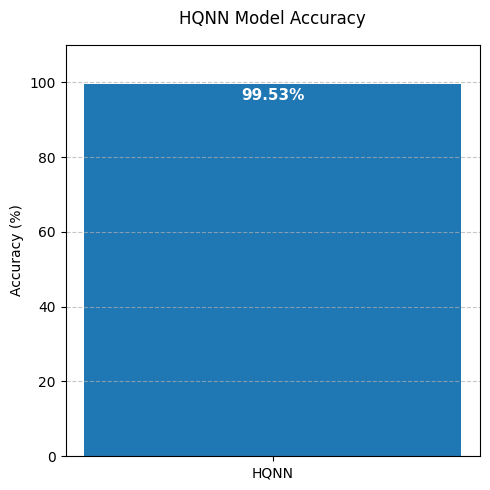

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
bars = plt.bar(["HQNN"], [hqnn_accuracy])

plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title("HQNN Model Accuracy", pad=15)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show accuracy value on bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height - 5,
        f"{hqnn_accuracy:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

plt.tight_layout()
plt.show()


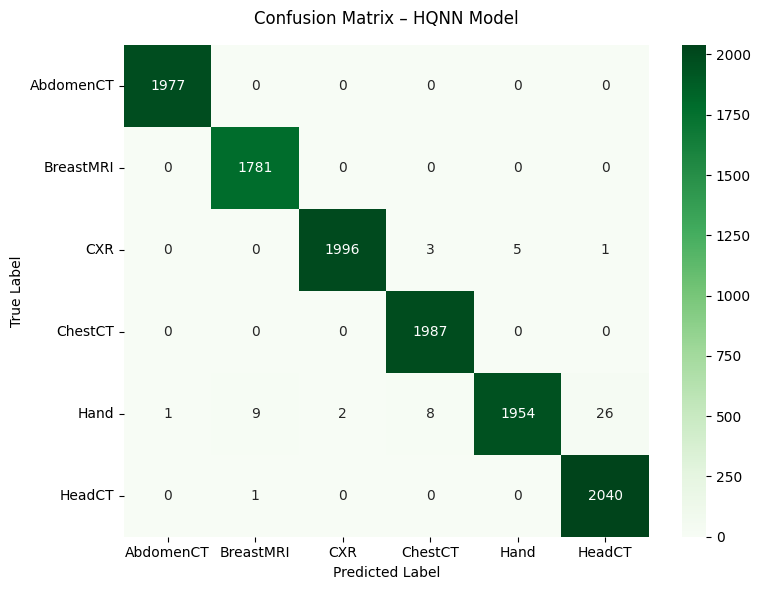

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

hqnn_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in hqnn_test_loader:
        features = features.to(device)
        labels = labels.to(device).long()

        outputs = hqnn_model(features)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm_hqnn = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_hqnn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=hqnn_dataset.classes,
    yticklabels=hqnn_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – HQNN Model", pad=15)
plt.tight_layout()
plt.show()


In [ ]:
class LCQHNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = LeanCNN()
        self.q_layer = hqnn_quantum_layer # Corrected from q_layer
        self.fc = nn.Linear(n_qubits, NUM_CLASSES)

    def forward(self, x):
        x = self.cnn(x)
        x = self.q_layer(x)
        return self.fc(x)

In [ ]:
model = LCQHNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.5600
Epoch 2, Loss: 0.1182
Epoch 3, Loss: 0.0592
Epoch 4, Loss: 0.0337
Epoch 5, Loss: 0.0212
Epoch 6, Loss: 0.0156
Epoch 7, Loss: 0.0112
Epoch 8, Loss: 0.0087
Epoch 9, Loss: 0.0084
Epoch 10, Loss: 0.0076


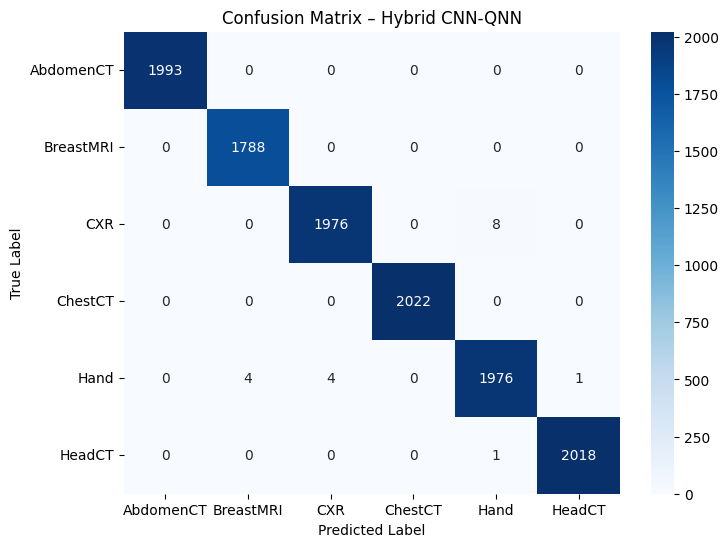

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).long()
        if labels.dim() > 1:
            labels = labels.squeeze()

        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Hybrid CNN-QNN")
plt.show()

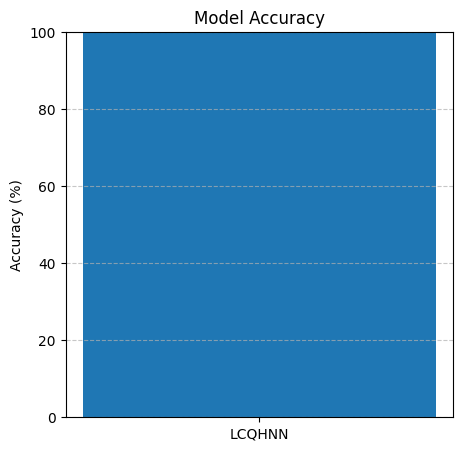

Test Accuracy: 99.85%


In [ ]:
# Calculate accuracy
LCQHNN_accuracy = 100 * np.trace(cm) / np.sum(cm)

plt.figure(figsize=(5, 5))
plt.bar(["LCQHNN"], [LCQHNN_accuracy])
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print(f"Test Accuracy: {LCQHNN_accuracy:.2f}%")


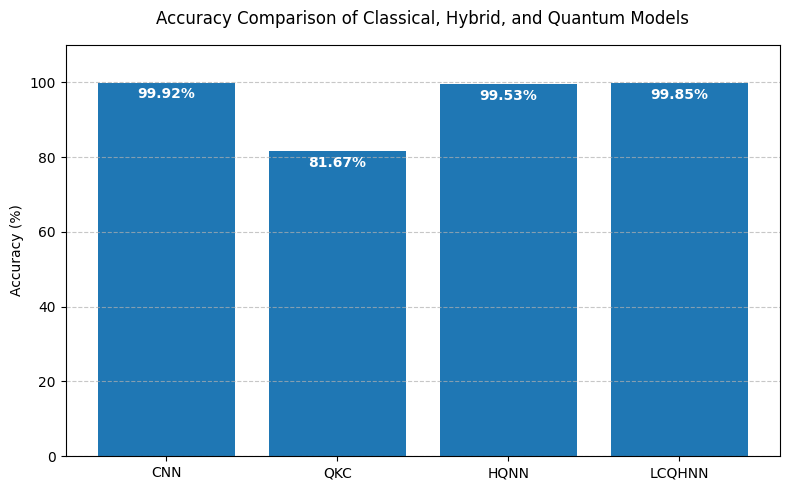

In [ ]:
import matplotlib.pyplot as plt

models = ["CNN", "QKC", "HQNN", "LCQHNN"]
accuracies = [cnn_accuracy, qkc_accuracy, hqnn_accuracy,LCQHNN_accuracy]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies)
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Classical, Hybrid, and Quantum Models", pad=15)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add accuracy values on bars
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 5,
        f"{acc:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="white"
    )

plt.tight_layout()
plt.show()


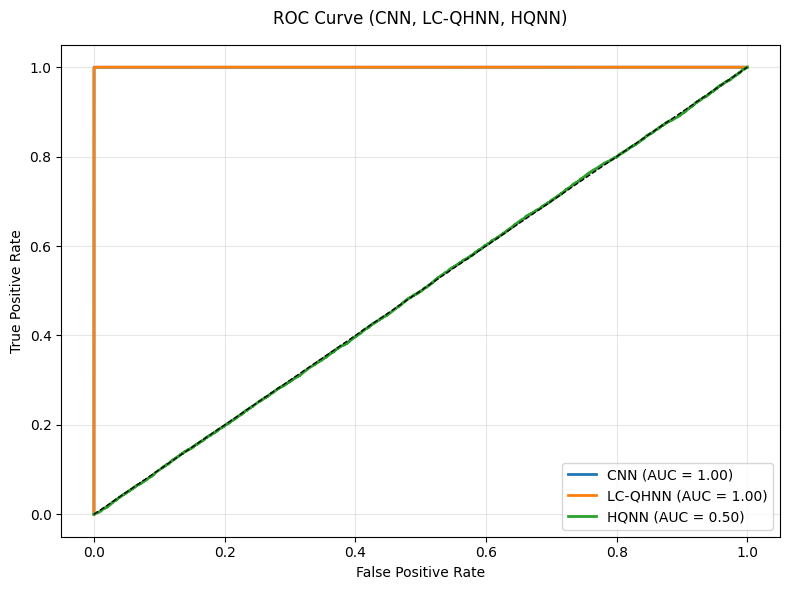

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def get_probs(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).long()
            if y.dim() > 1:
                y = y.squeeze()

            outputs = model(x)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    return np.vstack(all_probs), np.hstack(all_labels)

# Get probabilities
cnn_probs, y_true = get_probs(cnn_model, test_loader)
lcqhnn_probs, _ = get_probs(model, test_loader)
hqnn_probs, _ = get_probs(hqnn_model, hqnn_test_loader)

# Binarize labels
y_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

# ROC helper
def plot_roc(y_bin, probs, label):
    fpr, tpr, _ = roc_curve(y_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC = {roc_auc:.2f})")

# Plot
plt.figure(figsize=(8, 6))
plot_roc(y_bin, cnn_probs, "CNN")
plot_roc(y_bin, lcqhnn_probs, "LC-QHNN")
plot_roc(y_bin, hqnn_probs, "HQNN")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CNN, LC-QHNN, HQNN)", pad=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


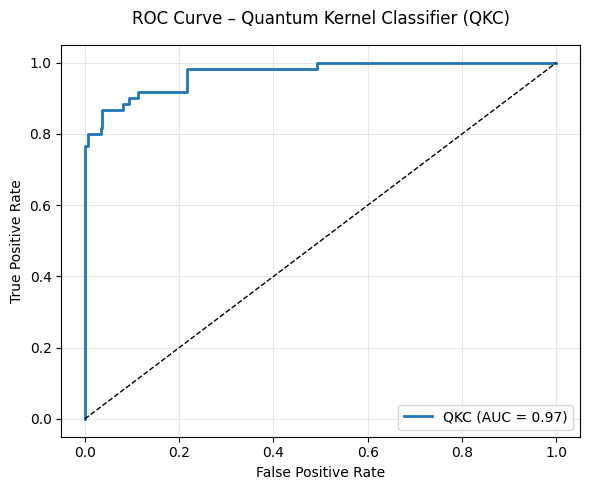

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
y_qkc_bin = label_binarize(y_test, classes=range(NUM_CLASSES))
qkc_scores = svm.decision_function(K_test)
fpr, tpr, _ = roc_curve(y_qkc_bin.ravel(), qkc_scores.ravel())
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"QKC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Quantum Kernel Classifier (QKC)", pad=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
